# Логистическая регрессия

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.datasets import load_iris

from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import RobustScaler, Normalizer

from sklearn.model_selection import train_test_split, cross_val_score  
from sklearn.model_selection import GridSearchCV, KFold, StratifiedShuffleSplit, RepeatedStratifiedKFold

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report

import sklearn
print(sklearn.__version__)


1.9.0


# Линейная модель

Линейные модели являются одними из самых простых и интуитивно монятных моделей машинного обучения. 

Напомним основы о которых мы с Вами говорили на 1 занятии.

У нас есть множество объектов (признаков) $X$, и каждому из них мы хотим сопоставить какое-то значение $y$. 

К примеру, у нас есть набор операций по банковской карте, а мы хотели бы, понять, какие из этих операций являются мошенническими. Если вы разделите все операции на два класса и нулём обозначите законные действия, а единицей мошеннические, то у вас получится простейшая задача классификации. 

Представьте другую ситуацию: у вас есть данные о годе выпуска, технических характеристиках и марках автомобилей, по которым мы хотели бы оценить стоимость этих автомобилей на вторичном рынке. Это пример задачи регрессии.

Таким образом, задачи классификации и регрессии можно сформулировать как поиск отображения из множества объектов $X$ в множество возможных $y$.

Математически задачи можно описать так:
- для  классификации $X\rightarrow \{0,1,..., k\}$ где $0,...,k$ - номера классов;
- для регрессии $X\rightarrow \mathbb{R}$, где $\mathbb{R}$ - вещественное число.


![ris01](pict/logreg.png)

## Логистическая регрессия

Основная идея логистической регрессии заключается в том, что пространство исходных значений может быть разделено линейной границей (т.е. прямой) на две соответствующих классам области.

В чем линейность границы? В случае одного измерения - это точка, для двух - это прямая, для трех плоскость и т.д.



Рассмотрим точку $(a,b)$. Подставляя значения $x_1$ и $x_2$ в граничную функцию, получим результат $w_1 x_1+ w_2x_2+w_0$. Теперь, в зависимости от положения  $(a,b)$ следует рассмотреть три варианта:
- $(a,b)$ лежит в области, ограниченной точками класса 1. Тогда $w_1 x_1+ w_2x_2+w_0 > 0$, будет положительной и пусть принимает значение +1 . С математической точки зрения, чем больше величина этого значения, тем больше расстояние между точкой и границей, пусть это означает большую вероятность того, что $(a,b)$ принадлежит классу классу 1. Следовательно, вероятность нахождения точки $(a,b)$ в данной области будет находиться в пределах $(0.5, 1]$.
- $(a,b)$ лежит в области, ограниченной точками класса класса 0. Теперь, $w_1 x_1+ w_2x_2+w_0 < 0$ будет отрицательной и принимать занчение -1. Но, как и в случае с положительным значением, чем больше величина выходного значения по модулю, тем больше вероятность, что точка $(a,b)$ принадлежит классу 0, и она находится в интервале $[0, 0.5)$.
- $(a,b)$ лежит на самой границе. В этом случае, $w_1 x_1+ w_2x_2+w_0 = 0$. Это означает, что модель действительно не может определить, принадлежит ли $(a,b)$ к классу 1 или к классу 0. И в результате вероятность будет равняться 0.5.


### Линейная функция

Напомним как выглядит линейная функция в n-мерном пространстве признаков (для i-ой строки наших данных):

$$ f_w(x_i) = w_1 x_1 + ... + w_n x_n + w_0, $$
 
где $f_w(x_i)$ – целевая переменная (target или $y_i$), $x_i = (x_{i,1},...,x_{i,n})$ – вектор, соответствующий объекту выборки (вектор признаков, мы их также называем фичами от английского features), а $w_1, ... ,w_n, w_0$  – параметры модели. Признаки ещё называют фичами (от английского features). 

Вектор $w = (w_1,...,w_n)$ часто называю (особенно в эконометрике) вектором весов, а число $w_0$
 – свободным коэффициентом, или сдвигом (bias). 
 
 Более компактно линейную модель можно записать в виде:
 
 $$ f_w(x_i) = \langle x_i,w \rangle + w_0 = x_i^T w + w_0  $$
 
 
 $$ \left(x_{i,1} ... x_{i,n}\right)\left( \begin{array}{c} w_{1}\\... \\ w_{n} \end{array}\right)+w_0 = 
 \left(1, x_{i,1} ... x_{i,n}\right)\left( \begin{array}{c} w_0\\ w_1\\... \\ w_n \end{array}\right)
 $$
 
Поскольку это сильно упрощает запись, в дальнейшем мы будем считать, что это уже сделано и зависимость имеет вид просто $f_w(x_i)=⟨w,x_i⟩$.
 
### Обобщим результат

Обратите внимание, что по осям расположены признаки, а целью является спрогнозировать принадлежность точек к классам $\{0,1\}$, при этом классы мы будем соотносить со значениями $\{-1, +1\}$. Фактически мы будем назначать -1 если точка будет находится ниже линейной разделительной функции и +1 если выше, при этом на задачу классификации мы будем смотреть с точки зрения предсказания вероятности соотнесения точки к классу.
 
Проблема состоит в том, что вероятность, по определению, величина от 0 до 1, а простого способа обучить линейную модель так, чтобы это ограничение соблюдалось, нет. 

Из этой ситуации можно выйти так: научить линейную модель правильно предсказывать какой-то объект, связанный с вероятностью, но с диапазоном значений $(-\infty, +\infty)$, и преобразовать ответы модели в вероятность. 

Искомой функцией является функция логит (logit) – логарифм отношения вероятности положительного события к отрицательному $\log\left(\frac{p}{1−p}\right)$

![ris02](pict/Logit.png)

Если ответом нашей модели является $\log\left(\frac{p}{1−p}\right)$, то искомую вероятность посчитать не трудно:
$$ \langle w, x_i\rangle = \log\left(\frac{p}{1−p}\right)$$
$$e^{\langle w, x_i \rangle} = \frac{p}{1−p}$$
$$p = \frac{1}{1+e^{-\langle w, x_i \rangle}}$$

Функция в правой части называется сигмоидой и обозначается:
$$\sigma(z) = \frac{1}{1+e^{-z}}$$
Таким образом, $p = \sigma \left(\langle w,x_i\rangle \right)$

Функцию потерь для логистической регрессии в бинарном варианте можно записать в  компактном виде:

$$ L (w,X,y) = -\sum_{i=1}^N \Big(  y_i \log(p_i) + (1 - y_i) \log(1-p_i)\Big)$$

Доказательство [данного момента можно посмотреть тут ...](https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture05-linclass.pdf)

Для [многоклассовой класификации тут ...](https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture06-linclass.pdf)
и тут используется для функция SoftMax для нормировки результата:
$$ SoftMax(z_1,...z_k) = \left( \dfrac{\exp(z_1)}{\sum_{j=1}^{k} \exp(z_k)}, ... , \dfrac{\exp(z_k)}{\sum_{j=1}^{k} \exp(z_k)} \right)$$
где $z_j = \langle w_j, x_i\rangle$, а $w$ подбираются для каждого класса по отдельности против всех остальных.


### Итог

Предсказание модели будет вычисляться, следующим образом:
$$p =\sigma\left(\langle w,x_i\rangle\right)$$

Это вероятность положительного класса, а как от неё перейти к предсказанию самого класса? 

Все наши предсказания положительные и находятся в диапазоне от 0 до 1. Что же делать? Интуитивным и не совсем (и даже совсем не) правильным является ответ «взять порог 0.5». 

Более корректным будет подобрать этот порог отдельно, для уже построенной регрессии минимизируя нужную вам метрику на отложенной валидационной выборке в процессе кросс-валидации выборке. Например, сделать так, чтобы доли предсказанных  классов примерно совпадала с реальной.

Отдельно заметим, что метод называется **логистической регрессией**, а не **логистической классификацией** именно потому, что предсказываем мы не классы, а вещественные числа – логиты (фактически вероятности).


![ris3](https://ds100.org/course-notes-su23/logistic_regression_2/logistic_reg_2_files/figure-html/cell-8-output-1.png)



## Проблема мультиколлениарности

Решаем систему линейных уравнений, при условии размерности $n\times m$ матрицы $X$:

$$ y = X w \Rightarrow  X^T y = X^T X w \Rightarrow  (X^TX)^{-1} X^T y = (X^TX)^{-1}(X^T X) w \Rightarrow (X^TX)^{-1} X^T y = w$$

и тут явная проблема, если в $X$ есть линейно зависимые строки, то обратная матрица несуществует из-за $Det(X^TX) = 0$, и при наличии "сильной" мультиколинеарности $w\rightarrow \infty$

тогда попытка решить задачу минимизации расхождения истинных и предсказанных значений становится проблематичной.

**Борьба с мультиколинеарноcтью - штрафы**

Самый простой способ добавить диагональную матрицу ("гребень")
$$w = (X^TX +\lambda I)^{-1} X^T y$$ 

Это так называемая $L_2$ - регуляризация.

Более сложная с математической точки $L_1$ и эластичная-регуляризация. 

Попробуем объяснить как это работает без значительного математического объяснения. Упростим считая, что нам известны истинные вероятности $y$. Тогда функция потерь минимизируется путем подбора $w$:

$$L(w,X,y) = \sum_{i=1}^n (y_i -\hat y_i) = \sum_{i=1}^n (y_i - X w) \rightarrow \min$$

Введем регуляризацию:
1. Lasso или $L_1$ или лассо
   $$ L(w,X,y)  = \sum_{i=1}^n (y_i - X w) + \lambda ||w|| $$
2. Ridge или $L_2$ или ридж или гребневая
    $$ L(w,X,y)  = \sum_{i=1}^n (y_i - X w) + \lambda w^2 $$
3. ElasticNet  или эластичная регрессия
   $$ L(w,X,y)  = \sum_{i=1}^n (y_i - X w) + \lambda_1 ||w|| + \lambda_2 w^2 $$


![ris05](pict/Lasso-Ridge-EN.png)

Что тут нарисовано? Здесь мы пытаемся минимизировать функцию потерь по двум фичам (признакам) $w_1$ и $w_2$ (на рисунке $\beta_1$ и $\beta_2$, рисунок цельнотянутый из интернетов, а перерисовывать было лень :). 

Это могут быть коэффициенты обычной линейной регрессии $y = w_2 x + w_1$.  По сути мы ищем такую точку на плоскости с координатами  $w_1$ и $w_2$, чтоб она соответствовала минимальной ошибке. И если бы у нас не было регуляризации, то нужно взять $w_1$ и $w_2$, такие, чтобы они давали нам $\hat y$ (на рисунке $\hat\beta$ )и все ок!

Но регуляризация требут физически ограничить значения  $w_1$ и $w_2$. Для каждого типа это залитые фигуры, при этом чем меньше $\lambda$, тем больше "радиус фигуры", при $\lambda = 0$ регуляризация отсутствует. Исходя из этого запишем:
1. $L_1$:  $|w_1|+|w_2|\le t$
2. $L_2$:  $w_1^2+ w_2^2 \le r$
3. ElasticNet:  $ w_1^2+ w_2^2 + |w_1|+|w_2| \le p$

Это требование выполняется только на границе и внутри соответствующей фигуры. Как же тогда быть? Наша функция потерь квадратичная - это параболоид (не путать с [гиперболоидом инженера Гарина ...](https://ru.wikipedia.org/wiki/Гиперболоид_инженера_Гарина_(фильм))), а тут мы смотрим на него "сферху" и по линиям уровня одинакового значения  $\hat y$ поднимаемся из Марианской впадины до касания с фигурой. И вот тут появляются интересные следствия этого касания ($L_1$ может занулить признак).

# Обработаем датасет ириски для примера применения логистической реграссии

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

X, y = load_iris(return_X_y=True)

clf = LogisticRegression(random_state=42, max_iter=500).fit(X, y)

clf.predict(X)
clf.score(X, y)

0.9733333333333334

### Параметры модели. 
**Важно работают в данном виде с версии 1.8**

Регулируем модель через `l1_ratio` - участие регуляризации l1` и `C` - сила регуляризации

- штрафа нет `l1_ratio=0`, `C=np.inf`
- `l1_ratio = 1` удаляет признаки практически не влияющие на ответ (количество признаков уменьшается), параметр силу регуляризации `0 < C < np.inf`
- `l1_ratio = 0` штрафует признаки практически не влияющие на ответ (количество признаков не меняется)
- `0 < l1_ratio < 1` одновременное применение `l1` и `l2`

**Внимание!** по умолчанию стоит опция `l1_ratio = 0` и `C = 1`


In [3]:
X, y = load_iris(return_X_y=True)


# Без регуляризации 
clf = LogisticRegression(random_state=42, l1_ratio=0, C=np.inf).fit(X, y)

clf.predict(X)
print(clf.score(X, y))
print( )
print('Коэффициенты')
print(clf.coef_)
print( )
print('Свободный член, для каждого класса')
print(clf.intercept_)

0.9866666666666667

Коэффициенты
[[  7.34741054  20.36734844 -30.2095218  -14.11848317]
 [ -2.43835606  -6.85009016  10.39822028  -2.07485129]
 [ -4.90905448 -13.51725828  19.81130152  16.19333447]]

Свободный член, для каждого класса
[  3.97232109  19.28077886 -23.25309995]


In [4]:
clf = LogisticRegression(random_state=42, l1_ratio=0).fit(X, y)

clf.predict(X)
clf.score(X, y)

/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9733333333333334

по умолчанию стоит 100 итераций для численного решения и нахождения весов. Но если нехватает увеличиваем это число.

In [5]:
clf = LogisticRegression(random_state=42, l1_ratio=0, max_iter=500).fit(X, y)

clf.predict(X)
clf.score(X, y)

print(clf.score(X, y))
print( )
print('Коэффициенты')
print(clf.coef_)
print( )
print('Свободный член, для каждого класса')
print(clf.intercept_)

0.9733333333333334

Коэффициенты
[[-0.42081301  0.96703206 -2.51880262 -1.08471313]
 [ 0.53230104 -0.31551883 -0.20482595 -0.94233837]
 [-0.11148804 -0.65151323  2.72362857  2.0270515 ]]

Свободный член, для каждого класса
[  9.84482249   2.22516707 -12.06998956]


## Контейнеры
**Важно!!!** Помните про измеримость растояний и их одинаковый масштаб? 

In [6]:
clf = make_pipeline(StandardScaler(),LogisticRegression(random_state=42, l1_ratio=0, max_iter=500))
clf = clf.fit(X, y)

In [7]:
clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [8]:
## нажмите стрелочку рядом с Pipeline и посмотрите имя шага контейнера
clf.predict(X)
print(clf.score(X, y))
print( )
print('Коэффициенты')
print(clf['logisticregression'].coef_)
print( )
print('Свободный член, для каждого класса')
print(clf['logisticregression'].intercept_)

0.9733333333333334

Коэффициенты
[[-1.07659238  1.15977648 -1.92814138 -1.81227307]
 [ 0.5899243  -0.36263595 -0.36461312 -0.82700241]
 [ 0.48666809 -0.79714052  2.2927545   2.63927548]]

Свободный член, для каждого класса
[-0.20463897  2.07455834 -1.86991938]


In [9]:
clf = make_pipeline(StandardScaler(),LogisticRegression(random_state=42, l1_ratio=1, solver = 'saga', max_iter=1000))
clf = clf.fit(X, y)
clf.predict(X)
print(clf.score(X, y))
print( )
print('Коэффициенты')
print(clf['logisticregression'].coef_)
print( )
print('Свободный член, для каждого класса')
print(clf['logisticregression'].intercept_)

0.9733333333333334

Коэффициенты
[[ 0.          0.92361345 -4.70893877  0.        ]
 [ 0.21785561  0.          0.          0.        ]
 [ 0.         -0.69769099  4.16973469  5.03318573]]

Свободный член, для каждого класса
[ 0.13598469  2.88464437 -3.02062906]


**Внимание!** Для решения оптимизационной задачи используются разные оптимизаторы, для нахождения оптимальной разделительной гиперплоскости, обратите внимание на комбинации `solver` и `l1_ratio` https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

## Построим модель

In [10]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [11]:
pipe = Pipeline([('preprocessing', MinMaxScaler()), 
                 ('clf',           LogisticRegression())])

cv = StratifiedShuffleSplit(test_size = .3, train_size = .6, n_splits = 10
                            , random_state = 42)
scaling = [ MinMaxScaler(), StandardScaler(),RobustScaler(), Normalizer()]

param_grid =[
    {'preprocessing': scaling,
     'clf__l1_ratio': [0], 
     'clf__solver': ['newton-cg' ,'lbfgs', 'sag', 'saga']},
    {'preprocessing': scaling,
     'clf__l1_ratio': [1], 
     'clf__solver': ['saga'],
     'clf__max_iter': [1000]},
    {'preprocessing': scaling,
     'clf__C': [np.inf], 
     'clf__solver': ['lbfgs','newton-cg']}
    ]

grid = GridSearchCV(pipe, param_grid, cv = cv, return_train_score = True)
grid.fit(X_train, y_train)
grid    

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'clf__l1_ratio': [0], 'clf__solver': ['newton-cg', 'lbfgs', ...], 'preprocessing': [MinMaxScaler(), StandardScaler(), ...]}, {'clf__l1_ratio': [1], 'clf__max_iter': [1000], 'clf__solver': ['saga'], 'preprocessing': [MinMaxScaler(), StandardScaler(), ...]}, ...]"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedShu...rain_size=0.6)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on thi

In [12]:
grid_result = pd.DataFrame(grid.cv_results_).sort_values(["rank_test_score",'std_test_score']).T
grid_result

,17,27,1,5,9,13,23,16,18,22,...,26,0,4,8,12,19,3,7,11,15
mean_fit_time,0.003581,0.003252,0.001684,0.001715,0.001094,0.001155,0.002882,0.002768,0.003125,0.002206,...,0.002962,0.002197,0.001772,0.000889,0.001003,0.000935,0.000939,0.002141,0.000714,0.000687
std_fit_time,0.001368,0.001384,0.000121,0.000711,0.000472,0.000463,0.001049,0.001254,0.001394,0.000895,...,0.001099,0.001188,0.000667,0.000336,0.000463,0.000017,0.000027,0.000991,0.000016,0.000014
mean_score_time,0.000369,0.00054,0.000341,0.000343,0.000379,0.000367,0.000433,0.0004,0.000307,0.000327,...,0.000386,0.000479,0.000365,0.000315,0.000341,0.000278,0.00028,0.000478,0.000317,0.000315
std_score_time,0.000172,0.000348,0.000031,0.000146,0.000158,0.000156,0.000209,0.000193,0.000135,0.000122,...,0.000234,0.000231,0.000165,0.000104,0.000127,0.000002,0.000002,0.00023,0.000004,0.000002
param_clf__l1_ratio,1.0,NaN,0.0,0.0,0.0,0.0,NaN,1.0,1.0,NaN,...,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
param_clf__solver,saga,newton-cg,newton-cg,lbfgs,sag,saga,lbfgs,saga,saga,lbfgs,...,newton-cg,newton-cg,lbfgs,sag,saga,saga,newton-cg,lbfgs,sag,saga
param_preprocessing,StandardScaler(),Normalizer(),StandardScaler(),StandardScaler(),StandardScaler(),StandardScaler(),Normalizer(),MinMaxScaler(),RobustScaler(),RobustScaler(),...,RobustScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),Normalizer(),Normalizer(),Normalizer(),Normalizer(),Normalizer()
param_clf__max_iter,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,1000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1000.0,NaN,NaN,NaN,NaN
param_clf__C,NaN,inf,NaN,NaN,NaN,NaN,inf,NaN,NaN,inf,...,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
params,"{'clf__l1_ratio': 1, 'clf__max_iter': 1000, 'c...","{'clf__C': inf, 'clf__solver': 'newton-cg', 'p...","{'clf__l1_ratio': 0, 'clf__solver': 'newton-cg...","{'clf__l1_ratio': 0, 'clf__solver': 'lbfgs', '...","{'clf__l1_ratio': 0, 'clf__solver': 'sag', 'pr...","{'clf__l1_ratio': 0, 'clf__solver': 'saga', 'p...","{'clf__C': inf, 'clf__solver': 'lbfgs', 'prepr...","{'clf__l1_ratio': 1, 'clf__max_iter': 1000, 'c...","{'clf__l1_ratio': 1, 'clf__max_iter': 1000, 'c...","{'clf__C': inf, 'clf__solver': 'lbfgs', 'prepr...",...,"{'clf__C': inf, 'clf__solver': 'newton-cg', 'p...","{'clf__l1_ratio': 0, 'clf__solver': 'newton-cg...","{'clf__l1_ratio': 0, 'clf__solver': 'lbfgs', '...","{'clf__l1_ratio': 0, 'clf__solver': 'sag', 'pr...","{'clf__l1_ratio': 0, 'clf__solver': 'saga', 'p...","{'clf__l1_ratio': 1, 'clf__max_iter': 1000, 'c...","{'clf__l1_ratio': 0, 'clf__solver': 'newton-cg...","{'clf__l1_ratio': 0, 'clf__solver': 'lbfgs', '...","{'clf__l1_ratio': 0, 'clf__solver': 'sag', 'pr...","{'clf__l1_ratio': 0, 'clf__solver': 'saga', 'p..."


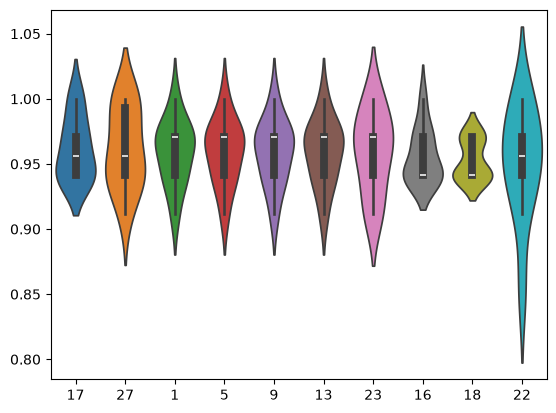

In [13]:
mask = grid_result.index[grid_result.index.str.endswith("_test_score")][:-3]
grid_result.columns = grid_result.columns.values.astype(str)
tabl = grid_result.loc[mask].iloc[:,:10]
sns.violinplot(data=tabl);

In [14]:
grid.cv_results_['params'][17]

{'clf__l1_ratio': 1,
 'clf__max_iter': 1000,
 'clf__solver': 'saga',
 'preprocessing': StandardScaler()}

In [15]:
grid.cv_results_['params'][1]

{'clf__l1_ratio': 0,
 'clf__solver': 'newton-cg',
 'preprocessing': StandardScaler()}

In [16]:
pipe_17_best = make_pipeline(StandardScaler(), LogisticRegression(solver = 'saga', l1_ratio = 1, max_iter = 1000) )
pipe_01 = make_pipeline(StandardScaler(), LogisticRegression(solver = 'newton-cg',l1_ratio = 0) )

pipe_17_best.fit(X_train,y_train)
pipe_01.fit(X_train,y_train)

y_pred_17_best = pipe_17_best.predict(X_test)
y_pred_01 = pipe_01.predict(X_test)

In [17]:
print('Первая модель')
print(classification_report(y_test, y_pred_17_best))

print('Третья модель')
print(classification_report(y_test, y_pred_01))

Первая модель
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Третья модель
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(l1_ratio=0, solver='newton-cg'))])


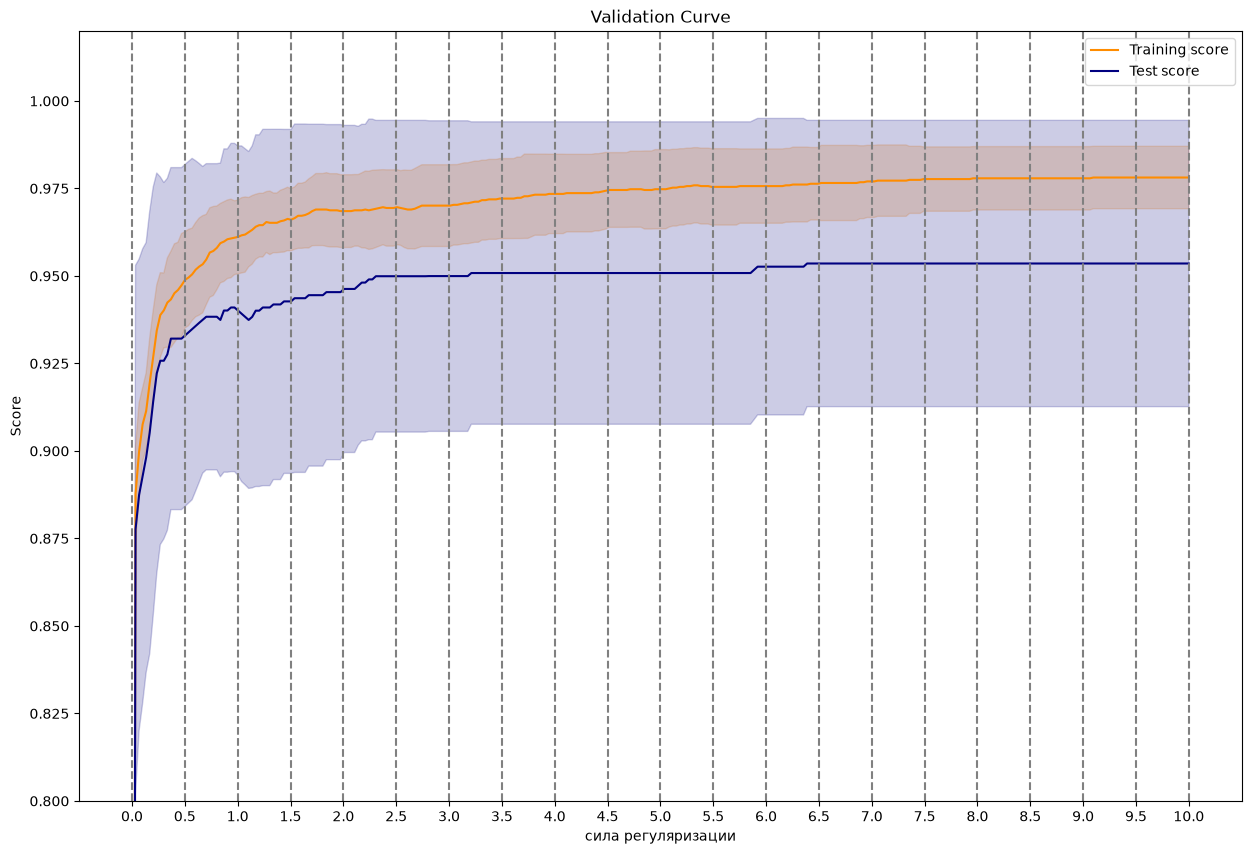

In [18]:
pipe_fin = make_pipeline( StandardScaler(), LogisticRegression(solver = 'newton-cg', l1_ratio = 0))
print(pipe_fin)

from sklearn.model_selection import validation_curve

cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats=10, random_state = 42)

n_range = np.linspace(0.0001, 10, 300)
train_scores, test_scores = validation_curve(
    pipe_fin , X_train, y_train,
    param_name = "logisticregression__C", 
    param_range = n_range,
    cv = cv, 
    scoring = "accuracy", 
    n_jobs = -1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(15,10))

plt.title("Validation Curve")
plt.xlabel("сила регуляризации")
plt.ylabel("Score")
plt.ylim(0.8, 1.02)

plt.plot(n_range, train_scores_mean, label="Training score", color="darkorange")
plt.fill_between(n_range, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2,
                 color="darkorange")
plt.plot(n_range, test_scores_mean, label="Test score",
             color="navy")
plt.fill_between(n_range, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.2,
                 color="navy")

plt.xticks(np.linspace(0, 10, 21))
for i in np.arange(0,10.1,0.5):
    plt.vlines(i, 0.8,1.02, linestyles='dashed', colors='gray')

plt.legend(loc="best")
plt.show();

In [19]:
pipe_end = make_pipeline( StandardScaler(), 
                         LogisticRegression(solver = 'newton-cg', l1_ratio = 0, C = 7))
pipe_end.fit(X_train,y_train)
y_pred_end = pipe_end.predict(X_test)
print(classification_report(y_test, y_pred_end))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

